# T2m diagnostics — CONUS box, forecast vs truth, and error maps

Standalone **Colab** notebook to visualize the *cached* outputs of `gencast_extreme_events_ensemble.ipynb`
(no model re-run needed — it only reads the saved `.nc` files).

It produces:
1. The **CONUS verification box** drawn on a world map (so you can see the analysis region).
2. Per event: **GenCast ensemble-mean** week-2 T2m anomaly vs **observed (ERA5)** truth, plus the **error** (forecast − truth).
3. A pooled **forecast-vs-truth scatter** + **error histogram** (a slope < 1 / compressed forecast = regression-to-climatology = damped extremes).

**Run top-to-bottom.** Point `OUT` below at the same folder the main notebook wrote to.

In [7]:
# Colab usually ships matplotlib / xarray / numpy; cartopy + netCDF4 often need installing.
!pip install -q cartopy netCDF4

In [8]:
import os, glob, numpy as np, xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- Point this at the SAME folder the main notebook wrote to ---
USE_DRIVE = True
if USE_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        OUT = "/content/drive/MyDrive/gencast_extreme_events"
    except Exception as e:
        print("Drive mount failed -> local fallback:", e)
        OUT = os.path.abspath("./gencast_extreme_events_out")
else:
    OUT = os.path.abspath("/content/gencast_extreme_events_out")

PRED_DIR  = f"{OUT}/predictions"
TRUTH_DIR = f"{OUT}/verif_truth"
FIG_DIR   = f"{OUT}/figures"
os.makedirs(FIG_DIR, exist_ok=True)
MODEL = "gencast"
print("OUT =", OUT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
OUT = /content/drive/MyDrive/gencast_extreme_events


In [9]:
# CONUS box. Data longitude is 0..360 (235..294); in -180..180 that is -125..-66.
LAT0, LAT1 = 24, 50
CONUS_EXTENT = [-125, -66, 22, 52]   # a little padding for context

def to_pm180(da):
    # Convert a 0..360 lon coordinate to -180..180 and sort (needed for plotting).
    return da.assign_coords(lon=(((da["lon"] + 180) % 360) - 180)).sortby("lon")

def discover_events():
    suffix = f"_{MODEL}_week2_t2m_anom_members.nc"
    files = sorted(glob.glob(f"{PRED_DIR}/*{suffix}"))
    return [os.path.basename(f)[:-len(suffix)] for f in files]

EVENTS = discover_events()
print(f"events with cached {MODEL} predictions:", EVENTS or "(none found — check OUT path)")

events with cached gencast predictions: ['California_HeatWave_2022', 'PNW_HeatDome_2021', 'PolarVortex_2019', 'Southwest_HeatWave_2020', 'WinterStorm_Elliott_2022', 'WinterStorm_Uri_2021']


## 1. CONUS verification box on the world map

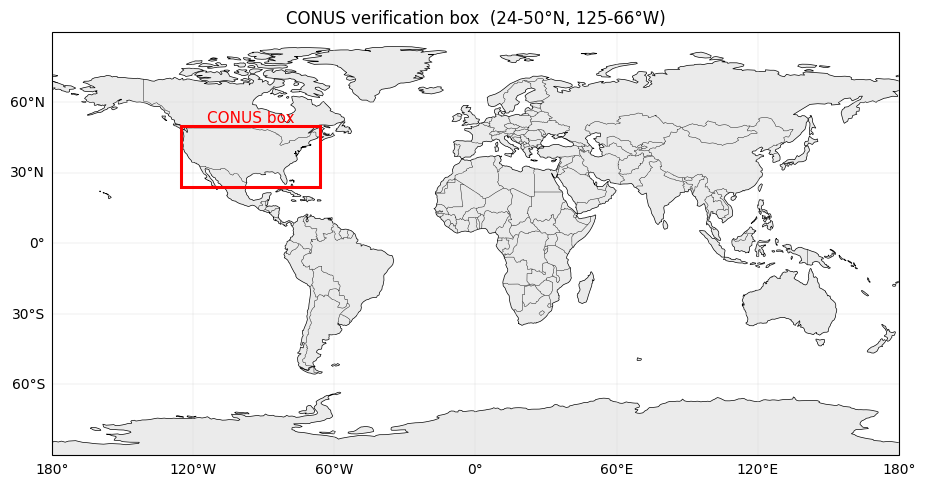

In [10]:
fig = plt.figure(figsize=(11, 5.5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()
ax.add_feature(cfeature.LAND, facecolor="0.92")
ax.add_feature(cfeature.OCEAN, facecolor="white")
ax.coastlines(linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="0.85")
gl.top_labels = gl.right_labels = False

# CONUS box: lower-left (-125, 24), width 59deg lon, height 26deg lat
ax.add_patch(mpatches.Rectangle((-125, 24), 59, 26, fill=False, edgecolor="red",
                                linewidth=2.2, transform=ccrs.PlateCarree(), zorder=5))
ax.text(-95.5, 51.5, "CONUS box", color="red", ha="center", fontsize=11,
        transform=ccrs.PlateCarree())
ax.set_title("CONUS verification box  (24-50°N, 125-66°W)")
fig.savefig(f"{FIG_DIR}/conus_box_worldmap.png", dpi=140, bbox_inches="tight")
plt.show()

## 2. Forecast vs truth vs error (week-2 T2m anomaly, per event)

Left = GenCast **best member** (the member with the lowest RMSE vs observations) · Middle = observed ERA5 anomaly · Right = error (best − truth).
The two anomaly panels share one symmetric color scale so you can compare amplitudes directly;
**even the best single member under-reaching the observed extreme is strong evidence the model damps extremes** (not just an ensemble-averaging artifact).
Truth is regridded onto the 1.0° prediction grid so the comparison is like-for-like.

California_HeatWave_2022


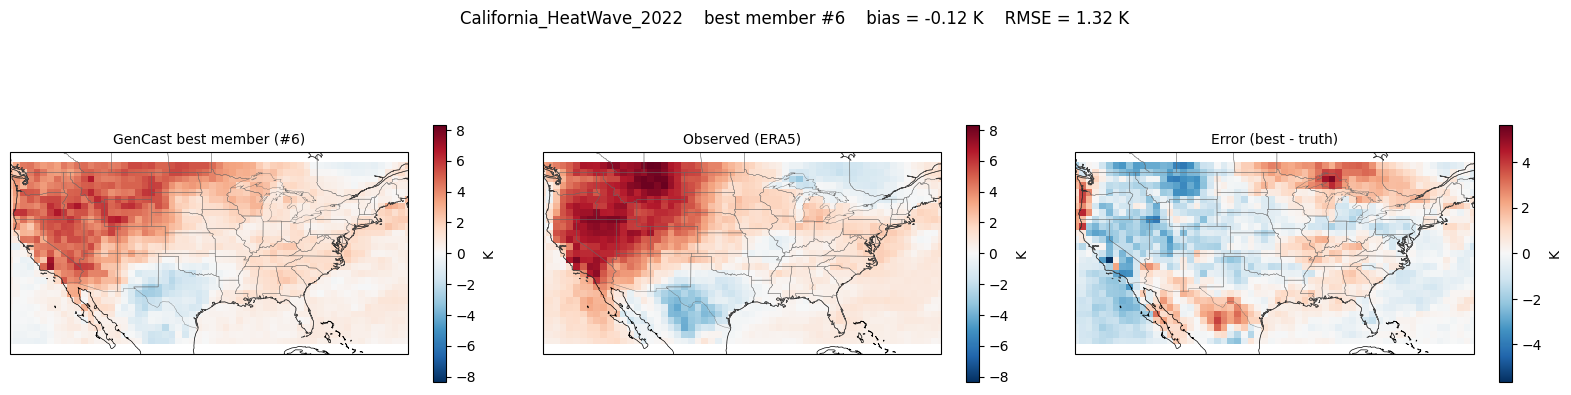

PNW_HeatDome_2021


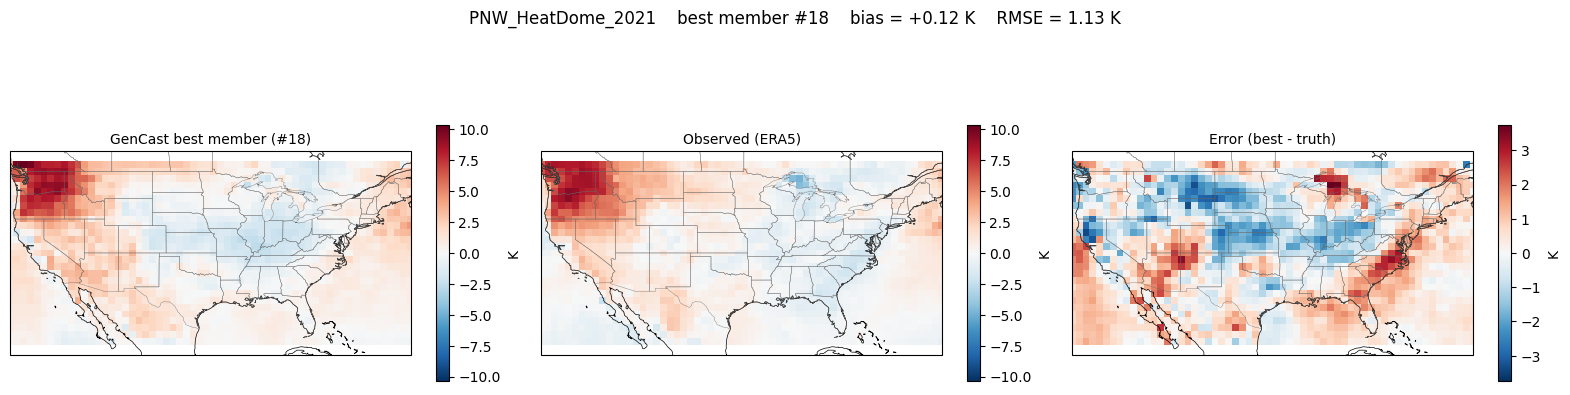

PolarVortex_2019


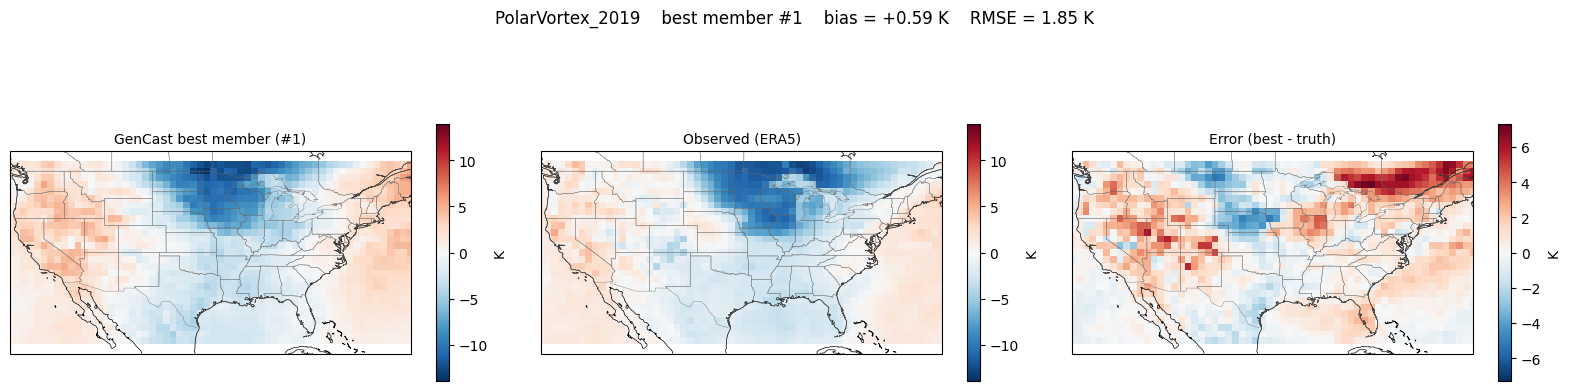

Southwest_HeatWave_2020


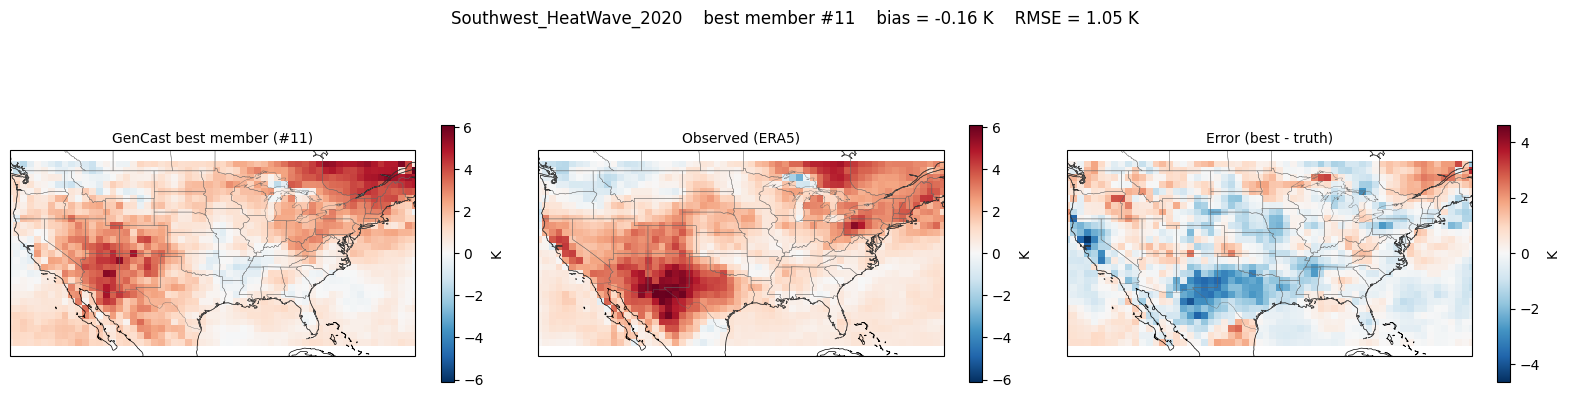

WinterStorm_Elliott_2022


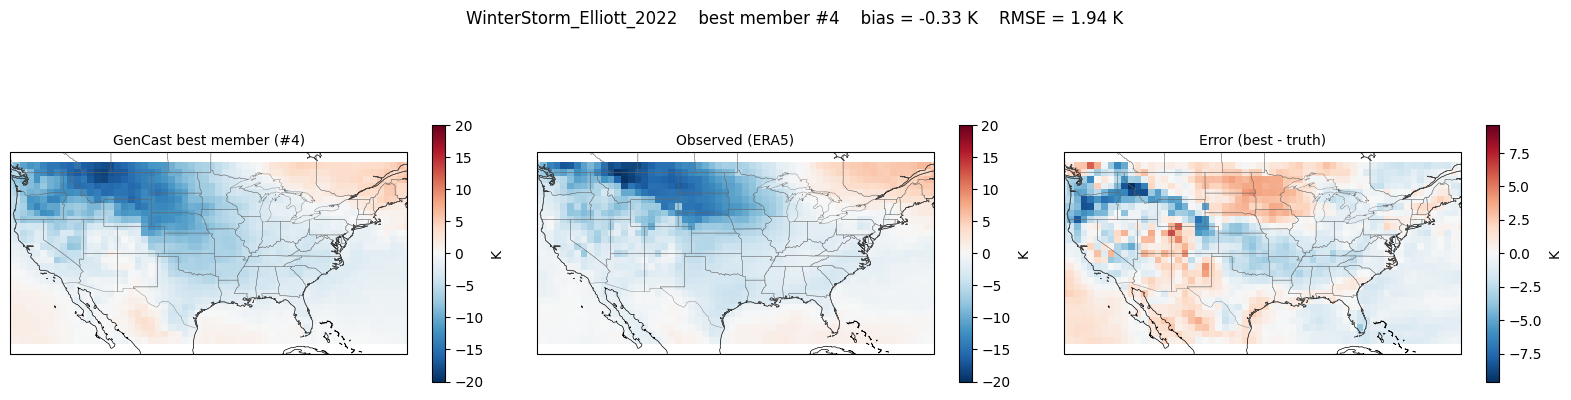

WinterStorm_Uri_2021


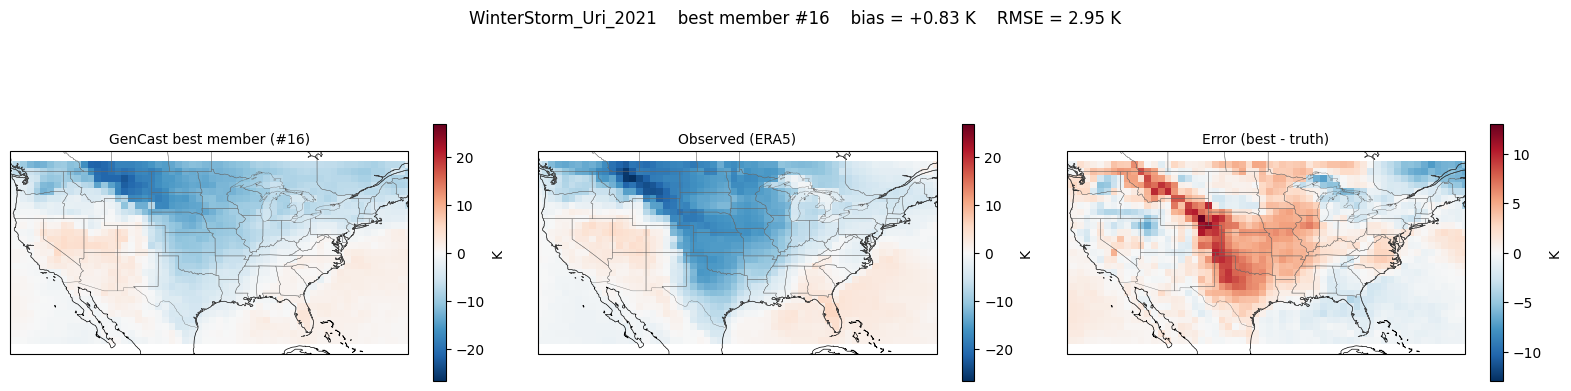

In [11]:
def load_event(name):
    truth = xr.open_dataset(f"{TRUTH_DIR}/{name}_true_week2_t2m_anom.nc")["t2m_anom"]
    pred  = xr.open_dataset(f"{PRED_DIR}/{name}_{MODEL}_week2_t2m_anom_members.nc")["t2m_anom"]
    # Truth is saved on the native 0.25deg ERA5 grid; predictions are on the coarser
    # model grid (1.0deg Mini). Regrid truth onto the prediction grid so panels/scatter
    # compare like-for-like (and .ravel() yields equal-length arrays).
    if (truth.sizes.get("lat") != pred.sizes.get("lat")
            or truth.sizes.get("lon") != pred.sizes.get("lon")):
        truth = truth.interp(lat=pred["lat"], lon=pred["lon"])
    return truth, pred

def best_member(pred, truth):
    # "Best" = the single member with the lowest RMSE vs the observed field.
    if "member" not in pred.dims:
        return pred, None
    dims = [d for d in pred.dims if d != "member"]
    rmse = np.sqrt(((pred - truth) ** 2).mean(dim=dims))
    k = int(rmse.argmin("member"))
    return pred.isel(member=k), k

def plot_event(name):
    truth, pred = load_event(name)
    fc, k = best_member(pred, truth)
    err = fc - truth
    amax = float(np.nanmax(np.abs(np.concatenate(
        [np.atleast_1d(fc.values).ravel(), np.atleast_1d(truth.values).ravel()]))))
    emax = float(np.nanmax(np.abs(err.values))) or 1.0
    fc_title = "GenCast best member" + (f" (#{k})" if k is not None else "")
    panels = [(fc_title, fc, amax),
              ("Observed (ERA5)",  truth, amax),
              ("Error (best - truth)", err, emax)]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.2),
                             subplot_kw={"projection": ccrs.PlateCarree()})
    for ax, (title, da, vmax) in zip(axes, panels):
        d = to_pm180(da)
        m = ax.pcolormesh(d["lon"], d["lat"], d.values, cmap="RdBu_r",
                          vmin=-vmax, vmax=vmax, shading="auto",
                          transform=ccrs.PlateCarree())
        ax.set_extent(CONUS_EXTENT, crs=ccrs.PlateCarree())
        ax.coastlines(linewidth=0.5)
        ax.add_feature(cfeature.STATES, linewidth=0.25, edgecolor="0.4")
        ax.set_title(title, fontsize=10)
        plt.colorbar(m, ax=ax, shrink=0.72, label="K")
    bias = float(err.mean()); rmse = float(np.sqrt((err**2).mean()))
    tag = f"best member #{k}" if k is not None else "single member"
    fig.suptitle(f"{name}    {tag}    bias = {bias:+.2f} K    RMSE = {rmse:.2f} K",
                 y=1.04, fontsize=12)
    fig.tight_layout()
    fig.savefig(f"{FIG_DIR}/{name}_{MODEL}_best_fc_truth_error.png", dpi=140, bbox_inches="tight")
    plt.show()

for name in EVENTS:
    print(name)
    plot_event(name)

## 3. Pooled forecast-vs-truth scatter & error distribution

Every CONUS grid point of every event, pooled. On the left, the dashed line is the 1:1 (perfect) line —
if the cloud is **flatter than 1:1** (forecast compressed toward 0), the model is damping extremes
(regression to climatology). On the right, a mean error away from 0 is a systematic bias.

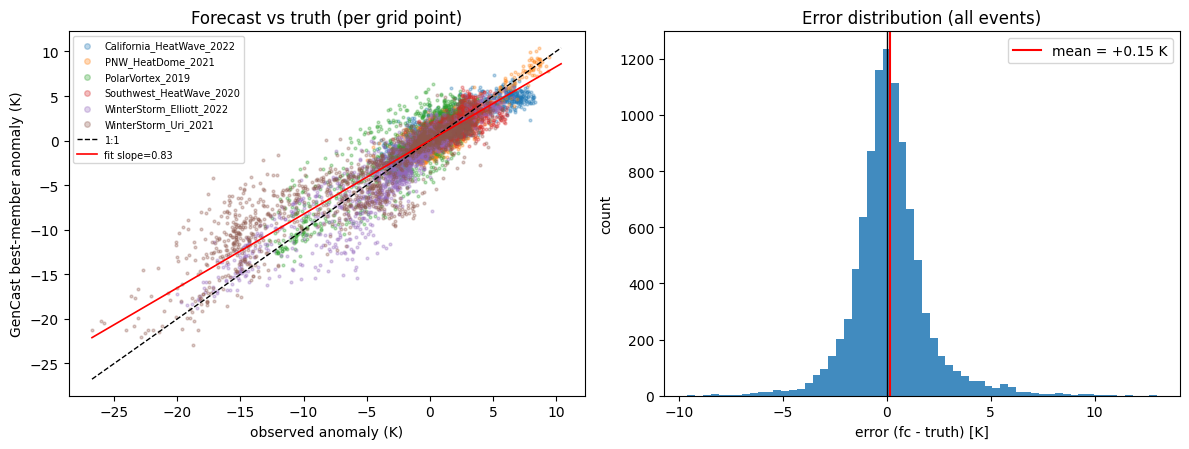

In [12]:
all_fc, all_tr = [], []
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))
for name in EVENTS:
    truth, pred = load_event(name)
    fc_da, _ = best_member(pred, truth)
    fc = fc_da.values.ravel()
    tr = truth.values.ravel()
    all_fc.append(fc); all_tr.append(tr)
    ax1.scatter(tr, fc, s=4, alpha=0.3, label=name)

if all_fc:
    all_fc = np.concatenate(all_fc); all_tr = np.concatenate(all_tr)
    good = np.isfinite(all_fc) & np.isfinite(all_tr)
    all_fc, all_tr = all_fc[good], all_tr[good]
    lim = [min(all_tr.min(), all_fc.min()), max(all_tr.max(), all_fc.max())]
    ax1.plot(lim, lim, "k--", lw=1, label="1:1")
    # least-squares slope (forecast vs truth): < 1 => damped extremes
    slope, intercept = np.polyfit(all_tr, all_fc, 1)
    ax1.plot(lim, np.polyval([slope, intercept], lim), "r-", lw=1.2,
             label=f"fit slope={slope:.2f}")
    ax1.set_xlabel("observed anomaly (K)"); ax1.set_ylabel("GenCast best-member anomaly (K)")
    ax1.set_title("Forecast vs truth (per grid point)")
    ax1.legend(fontsize=7, markerscale=2)

    err = all_fc - all_tr
    ax2.hist(err, bins=60, color="tab:blue", alpha=0.85)
    ax2.axvline(0, color="k", lw=1)
    ax2.axvline(err.mean(), color="red", lw=1.5, label=f"mean = {err.mean():+.2f} K")
    ax2.set_xlabel("error (fc - truth) [K]"); ax2.set_ylabel("count")
    ax2.set_title("Error distribution (all events)"); ax2.legend()
    fig.tight_layout()
    fig.savefig(f"{FIG_DIR}/t2m_scatter_error.png", dpi=140, bbox_inches="tight")
plt.show()